# Step 0: Import Libraries

In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Step 1: Data Loading

1.1 Load Dataset

In [10]:
file_path = r"data-final.csv"

df = pd.read_csv(
    file_path,
    sep="\t"
)

1.2 Check Dataset Shape

In [11]:
print("Number of rows and columns:")
print(df.shape)

Number of rows and columns:
(1015341, 110)


1.3 Display

In [12]:
df.head()

,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,...,dateload,screenw,screenh,introelapse,testelapse,endelapse,IPC,country,lat_appx_lots_of_err,long_appx_lots_of_err
0,4.0,1.0,5.0,2.0,5.0,1.0,5.0,2.0,4.0,1.0,...,2016-03-03 02:01:01,768.0,1024.0,9.0,234.0,6,1,GB,51.5448,0.1991
1,3.0,5.0,3.0,4.0,3.0,3.0,2.0,5.0,1.0,5.0,...,2016-03-03 02:01:20,1360.0,768.0,12.0,179.0,11,1,MY,3.1698,101.706
2,2.0,3.0,4.0,4.0,3.0,2.0,1.0,3.0,2.0,5.0,...,2016-03-03 02:01:56,1366.0,768.0,3.0,186.0,7,1,GB,54.9119,-1.3833
3,2.0,2.0,2.0,3.0,4.0,2.0,2.0,4.0,1.0,4.0,...,2016-03-03 02:02:02,1920.0,1200.0,186.0,219.0,7,1,GB,51.75,-1.25
4,3.0,3.0,3.0,3.0,5.0,3.0,3.0,5.0,3.0,4.0,...,2016-03-03 02:02:57,1366.0,768.0,8.0,315.0,17,2,KE,1.0,38.0


1.4 Check Column Names

In [13]:
print(df.columns.tolist())

['EXT1', 'EXT2', 'EXT3', 'EXT4', 'EXT5', 'EXT6', 'EXT7', 'EXT8', 'EXT9', 'EXT10', 'EST1', 'EST2', 'EST3', 'EST4', 'EST5', 'EST6', 'EST7', 'EST8', 'EST9', 'EST10', 'AGR1', 'AGR2', 'AGR3', 'AGR4', 'AGR5', 'AGR6', 'AGR7', 'AGR8', 'AGR9', 'AGR10', 'CSN1', 'CSN2', 'CSN3', 'CSN4', 'CSN5', 'CSN6', 'CSN7', 'CSN8', 'CSN9', 'CSN10', 'OPN1', 'OPN2', 'OPN3', 'OPN4', 'OPN5', 'OPN6', 'OPN7', 'OPN8', 'OPN9', 'OPN10', 'EXT1_E', 'EXT2_E', 'EXT3_E', 'EXT4_E', 'EXT5_E', 'EXT6_E', 'EXT7_E', 'EXT8_E', 'EXT9_E', 'EXT10_E', 'EST1_E', 'EST2_E', 'EST3_E', 'EST4_E', 'EST5_E', 'EST6_E', 'EST7_E', 'EST8_E', 'EST9_E', 'EST10_E', 'AGR1_E', 'AGR2_E', 'AGR3_E', 'AGR4_E', 'AGR5_E', 'AGR6_E', 'AGR7_E', 'AGR8_E', 'AGR9_E', 'AGR10_E', 'CSN1_E', 'CSN2_E', 'CSN3_E', 'CSN4_E', 'CSN5_E', 'CSN6_E', 'CSN7_E', 'CSN8_E', 'CSN9_E', 'CSN10_E', 'OPN1_E', 'OPN2_E', 'OPN3_E', 'OPN4_E', 'OPN5_E', 'OPN6_E', 'OPN7_E', 'OPN8_E', 'OPN9_E', 'OPN10_E', 'dateload', 'screenw', 'screenh', 'introelapse', 'testelapse', 'endelapse', 'IPC', 'count

1.5 Check Missing Values

In [14]:
missing_values = df.isnull().sum()

print("Missing values per column:")
print(missing_values)

Missing values per column:
EXT1                     1783
EXT2                     1783
EXT3                     1783
EXT4                     1783
EXT5                     1783
                         ... 
endelapse                   0
IPC                         0
country                    77
lat_appx_lots_of_err        0
long_appx_lots_of_err       0
Length: 110, dtype: int64


1.6 Check info

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1015341 entries, 0 to 1015340
Columns: 110 entries, EXT1 to long_appx_lots_of_err
dtypes: float64(104), int64(2), str(4)
memory usage: 852.1 MB


1.7 Check Duplicate Rows

In [17]:
duplicates = df.duplicated().sum()

print("Number of duplicate rows:")
print(duplicates)

Number of duplicate rows:
0


# Step 2: Data Cleaning & Preparation

2.1 Select 50 Personality Question Columns

In [31]:

personality_columns = (
    [f'EXT{i}' for i in range(1, 11)] +
    [f'EST{i}' for i in range(1, 11)] +
    [f'AGR{i}' for i in range(1, 11)] +
    [f'CSN{i}' for i in range(1, 11)] +
    [f'OPN{i}' for i in range(1, 11)]
)

df_personality = df[personality_columns]

print("Number of personality columns:")
print(len(df_personality.columns))

Number of personality columns:
50


2.2 Check Value Range (1–5)

In [32]:
invalid_values = (
    (df_personality < 1) |
    (df_personality > 5)
)

invalid_count = invalid_values.sum().sum()

print("Number of invalid values:")
print(invalid_count)

Number of invalid values:
370370


2.3 Remove Invalid Responses

In [28]:
df_clean = df_personality[
    ~invalid_values.any(axis=1)
]

print("Shape after removing invalid rows:")
print(df_clean.shape)

Shape after removing invalid rows:
(876217, 50)


2.4 Select 7 Target Behaviors

In [30]:
target_columns = [
    'CSN6',
    'AGR9',
    'AGR5',
    'EXT4',
    'EST7',
    'OPN3',
    'OPN10'
]

print("Target variables:")
print(target_columns)

Target variables:
['CSN6', 'AGR9', 'AGR5', 'EXT4', 'EST7', 'OPN3', 'OPN10']


2.5 Define Features & Target

In [33]:
feature_columns = [
    col for col in df_clean.columns
    if col not in target_columns
]

X = df_clean[feature_columns]

print("Number of features:")
print(len(feature_columns))

Number of features:
43


2.6 Check Final Dataset

In [34]:
print("Final dataset shape:")
print("Features (X):", X.shape)
print("Targets:", len(target_columns))

Final dataset shape:
Features (X): (876217, 43)
Targets: 7


# Step 3: EDA (Exploratory Data Analysis)

3.1 Distribution of Target Variables

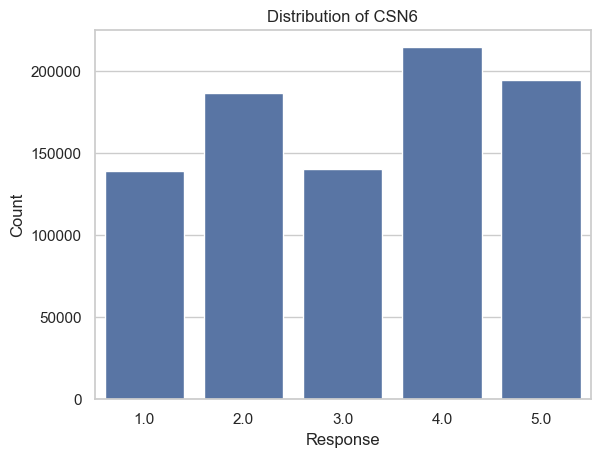

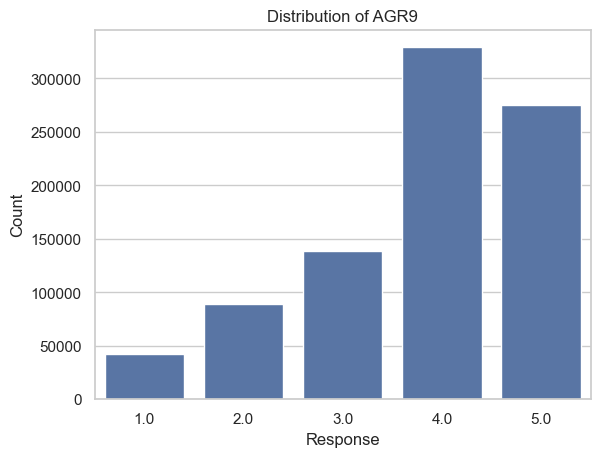

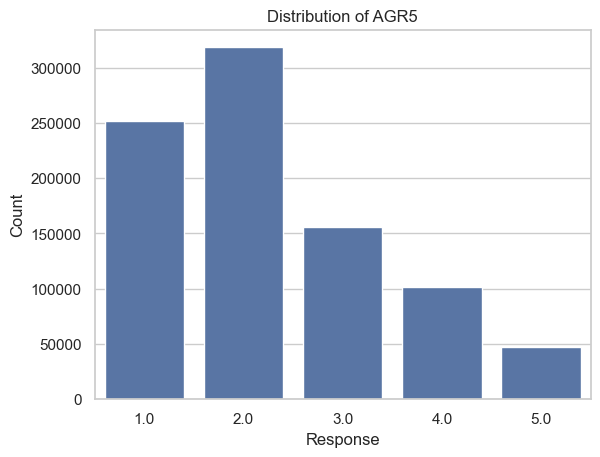

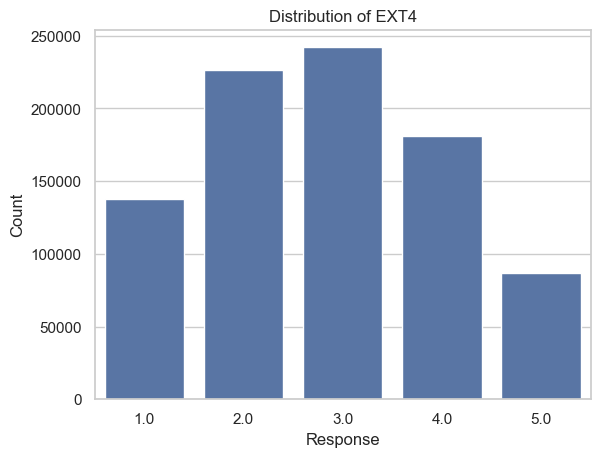

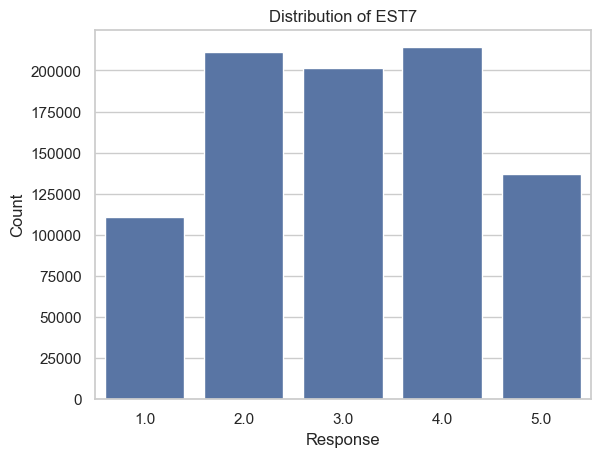

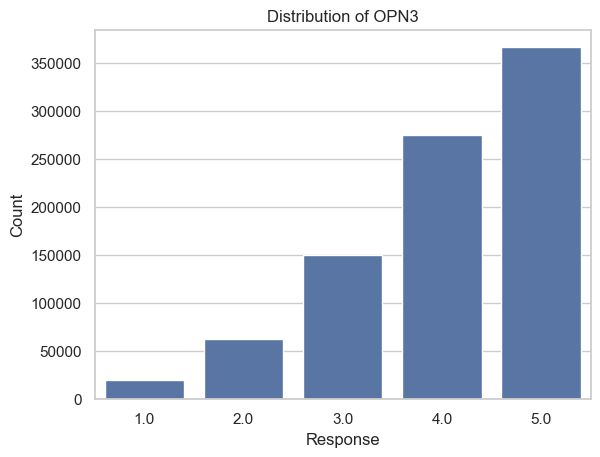

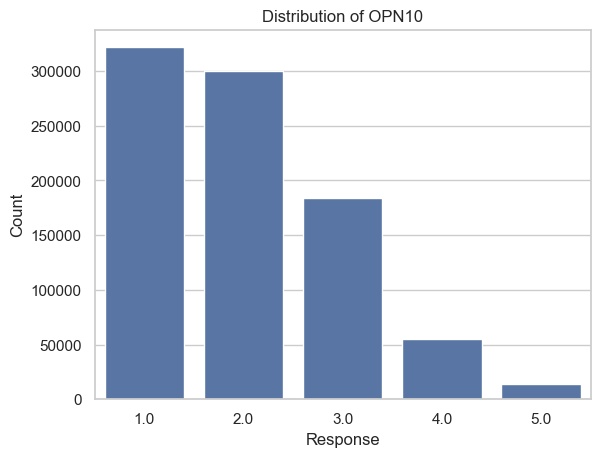

In [35]:
for col in target_columns:

    plt.figure()

    sns.countplot(
        x=df_clean[col]
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel("Response")
    plt.ylabel("Count")
    plt.show()

3.2 Histogram of All Features


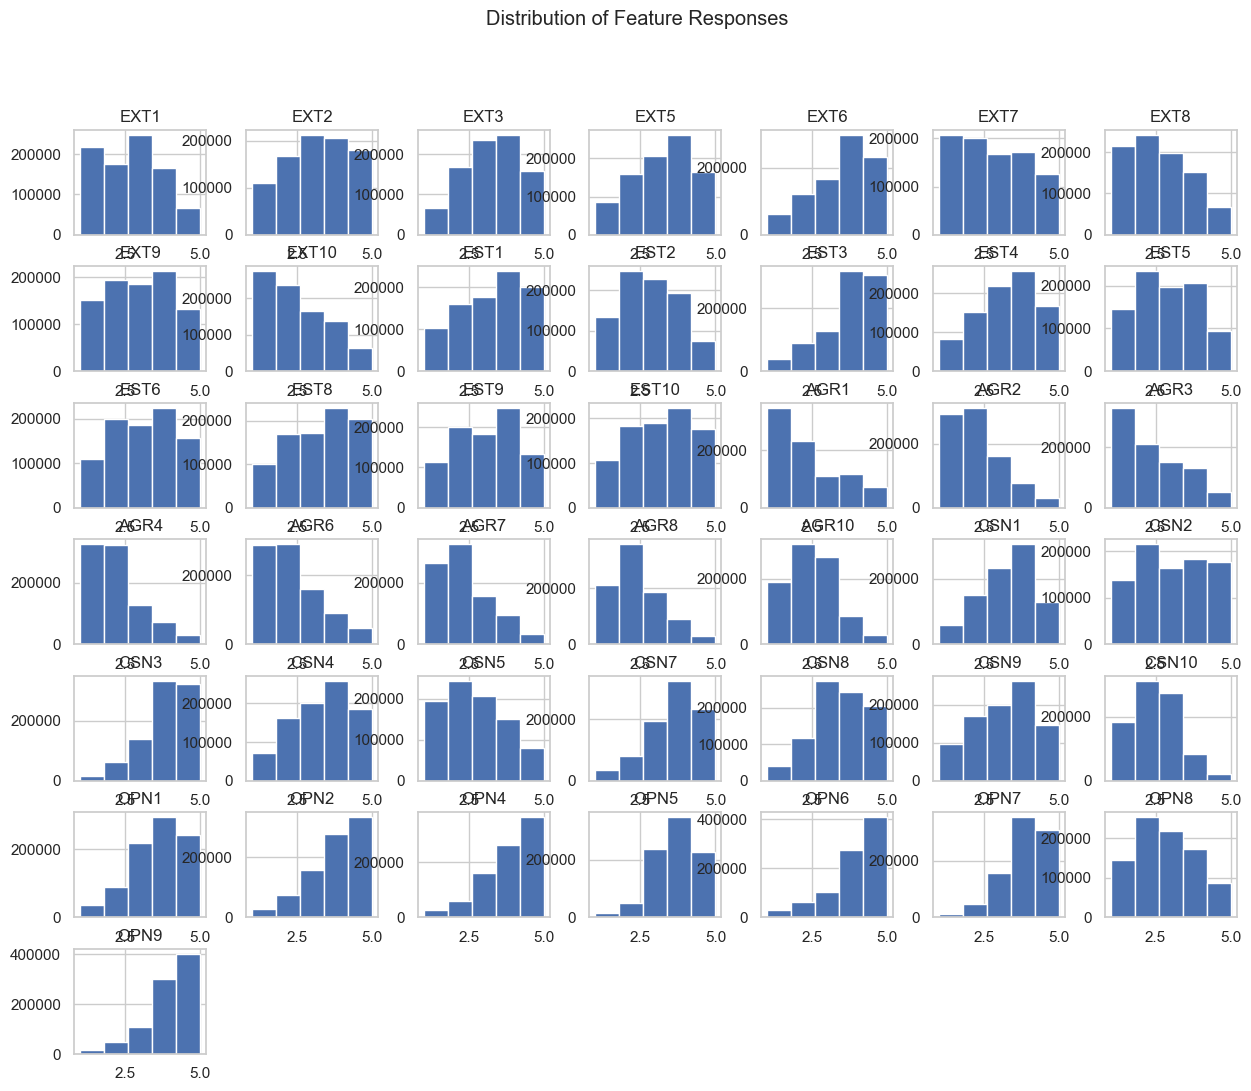

In [36]:
X.hist(
    bins=5,
    figsize=(15, 12)
)

plt.suptitle(
    "Distribution of Feature Responses"
)

plt.show()

3.3 Correlation Matrix

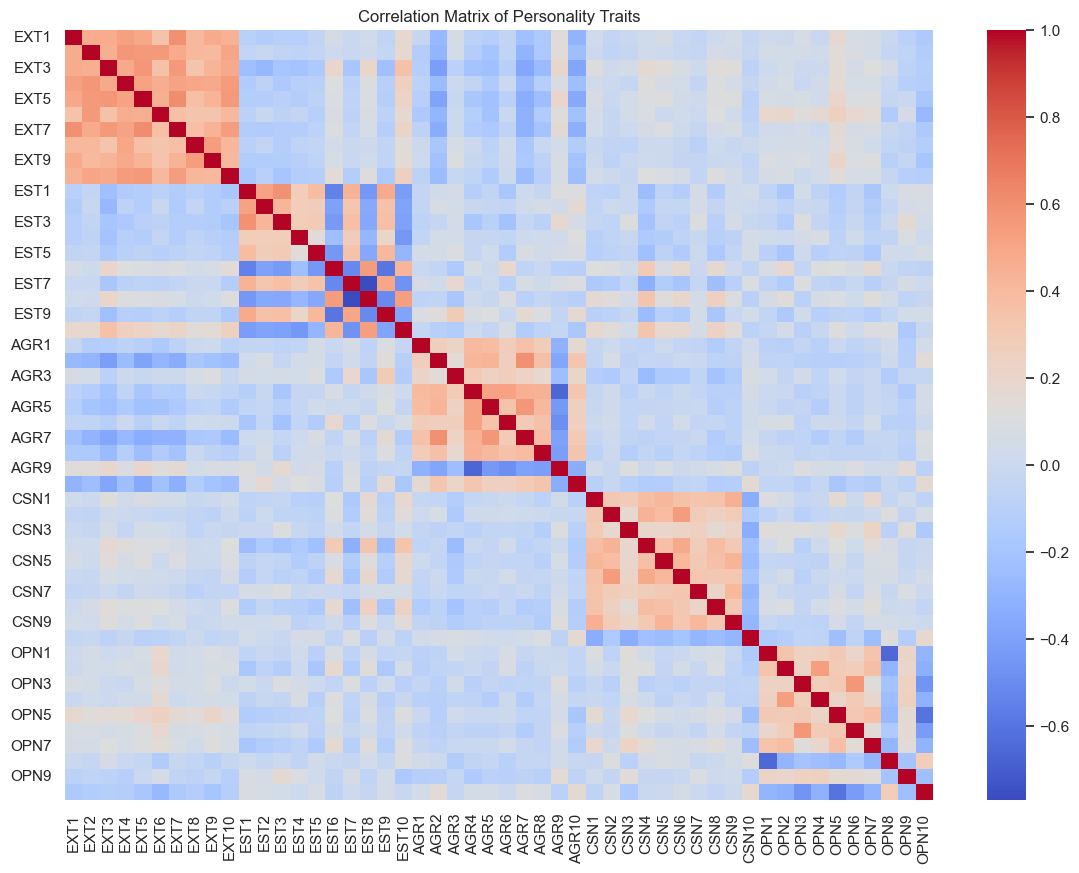

In [37]:
correlation_matrix = df_clean.corr()

plt.figure(
    figsize=(14, 10)
)

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm"
)

plt.title(
    "Correlation Matrix of Personality Traits"
)

plt.show()

3.4 Boxplot of Target Behaviors

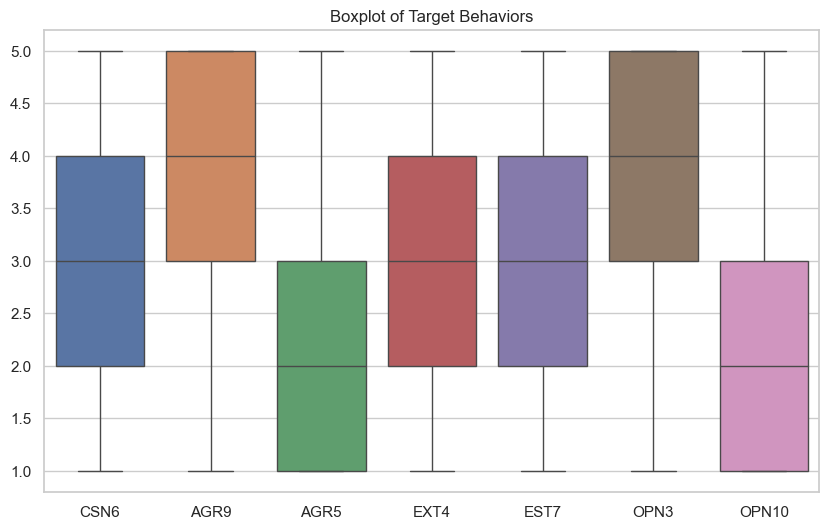

In [41]:
plt.figure(
    figsize=(10, 6)
)

sns.boxplot(
    data=df_clean[target_columns]
)

plt.title(
    "Boxplot of Target Behaviors"
)

plt.show()

3.5 Average Score of Each Personality Dimension

In [46]:
df_clean["Extraversion"] = df_clean[
    [f"EXT{i}" for i in range(1, 11)]
].mean(axis=1)

df_clean["Neuroticism"] = df_clean[
    [f"EST{i}" for i in range(1, 11)]
].mean(axis=1)

df_clean["Agreeableness"] = df_clean[
    [f"AGR{i}" for i in range(1, 11)]
].mean(axis=1)

df_clean["Conscientiousness"] = df_clean[
    [f"CSN{i}" for i in range(1, 11)]
].mean(axis=1)

df_clean["Openness"] = df_clean[
    [f"OPN{i}" for i in range(1, 11)]
].mean(axis=1)

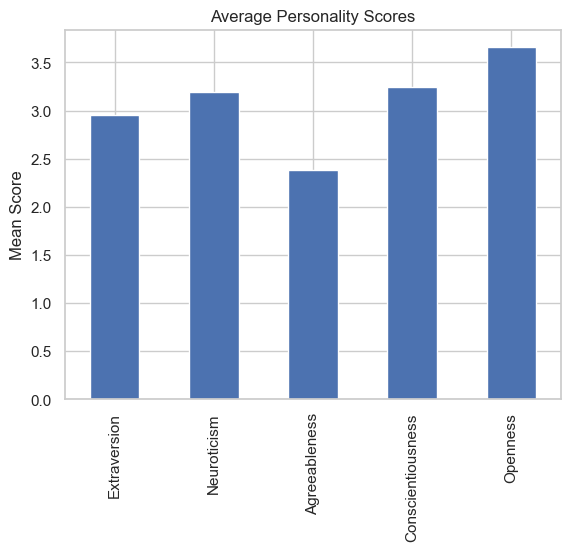

In [47]:
traits = [
    "Extraversion",
    "Neuroticism",
    "Agreeableness",
    "Conscientiousness",
    "Openness"
]

mean_scores = df_clean[traits].mean()

plt.figure()

mean_scores.plot(
    kind="bar"
)

plt.title(
    "Average Personality Scores"
)

plt.ylabel(
    "Mean Score"
)

plt.show()

# Step 4: Model Training (Naive Bayes)

4.1 Train-Test Split

In [62]:
from sklearn.model_selection import train_test_split

example_target = target_columns[0]

y_example = df_clean[example_target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_example,
    test_size=0.2,
    random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (700973, 43)
Testing set size: (175244, 43)


4.2 Train Naive Bayes Model (Single Target)

In [85]:
from sklearn.naive_bayes import GaussianNB

# Remove rows where y is NaN
mask = y_train.notna()

X_train = X_train[mask]
y_train = y_train[mask]

model = GaussianNB()

model.fit(
    X_train,
    y_train
)

print("Model training completed")

Model training completed


4.3 Train Models for All 7 Behaviors

In [86]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

models = {}

for target in target_columns:

    print("Training model for:", target)

    mask = df_clean[target].notna()

    X_target = X[mask]
    y_target = df_clean[target][mask]

    X_train, X_test, y_train, y_test = train_test_split(
        X_target,
        y_target,
        test_size=0.2,
        random_state=42
    )

    model = GaussianNB()

    model.fit(
        X_train,
        y_train
    )

    models[target] = model

print("All models trained successfully")

Training model for: CSN6
Training model for: AGR9
Training model for: AGR5
Training model for: EXT4
Training model for: EST7
Training model for: OPN3
Training model for: OPN10
All models trained successfully


4.4 Store Training and Testing Sets

In [87]:
datasets = {}

for target in target_columns:

    y = df_clean[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    datasets[target] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }

print("Datasets stored successfully")

Datasets stored successfully


# Step 5: Model Evaluation

5.1 Predict on Test Data

In [88]:
predictions = {}

for target in target_columns:

    model = models[target]

    X_test = datasets[target]["X_test"]

    X_test = X_test.fillna(X_test.mean())

    y_pred = model.predict(X_test)

    predictions[target] = y_pred

print("Predictions completed")

Predictions completed


5.2 Calculate Evaluation Metrics

In [89]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

evaluation_results = {}

for target in target_columns:

    y_test = datasets[target]["y_test"]
    y_pred = predictions[target]

    # remove NaN rows
    mask = y_test.notna()

    y_test_clean = y_test[mask]
    y_pred_clean = y_pred[mask]

    accuracy = accuracy_score(
        y_test_clean,
        y_pred_clean
    )

    precision = precision_score(
        y_test_clean,
        y_pred_clean,
        average="weighted"
    )

    recall = recall_score(
        y_test_clean,
        y_pred_clean,
        average="weighted"
    )

    f1 = f1_score(
        y_test_clean,
        y_pred_clean,
        average="weighted"
    )

    evaluation_results[target] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }

print("Evaluation completed")

Evaluation completed


5.3 Create Performance Table

In [90]:
results_df = pd.DataFrame(
    evaluation_results
).T

results_df

,Accuracy,Precision,Recall,F1-score
CSN6,0.441523,0.427567,0.441523,0.428408
AGR9,0.533913,0.530981,0.533913,0.530358
AGR5,0.498433,0.493699,0.498433,0.493105
EXT4,0.480833,0.480069,0.480833,0.476177
EST7,0.496135,0.490406,0.496135,0.491014
OPN3,0.505649,0.516691,0.505649,0.508391
OPN10,0.523564,0.541930,0.523564,0.530321


5.4 Confusion Matrix

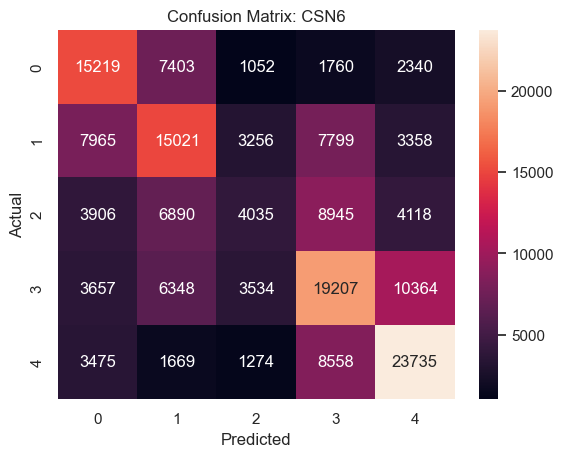

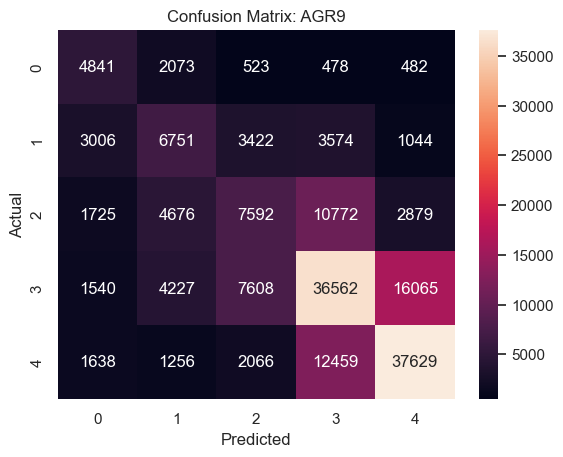

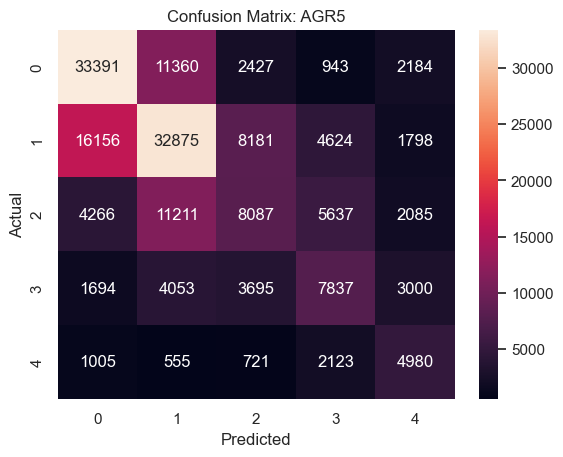

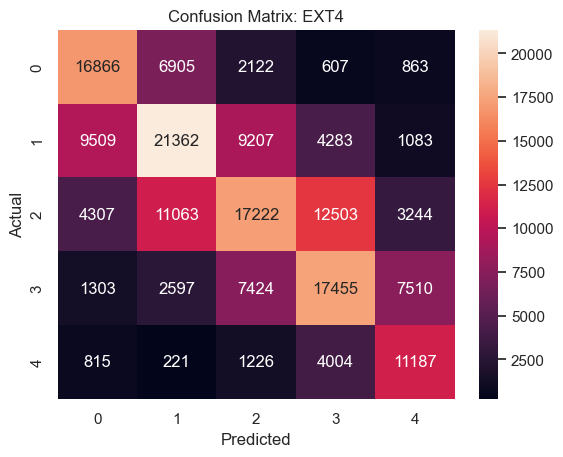

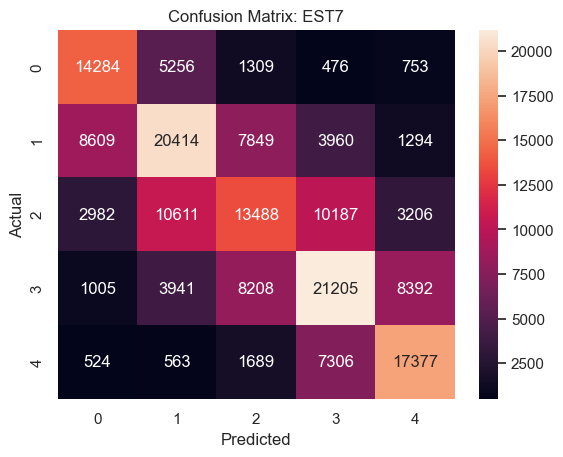

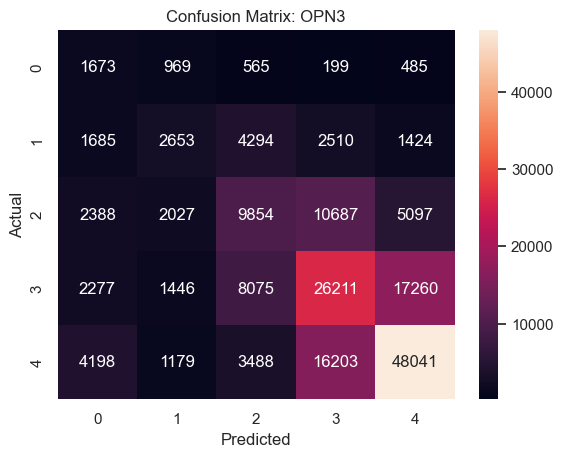

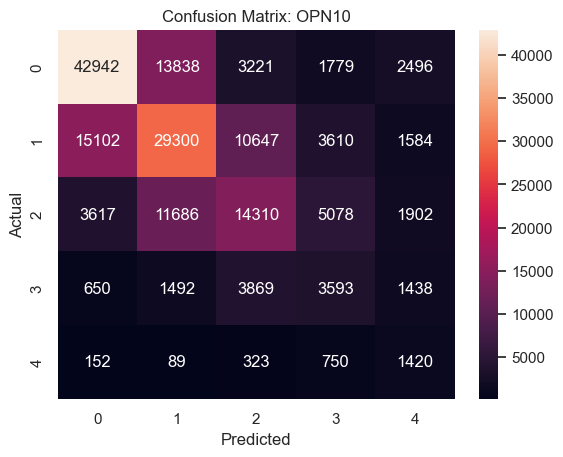

In [94]:
for target in target_columns:

    y_test = datasets[target]["y_test"]

    y_pred = pd.Series(
        predictions[target],
        index=y_test.index
    )

    y_test_clean = y_test.dropna()
    y_pred_clean = y_pred.loc[y_test_clean.index]

    cm = confusion_matrix(
        y_test_clean,
        y_pred_clean
    )

    plt.figure()

    sns.heatmap(
        cm,
        annot=True,
        fmt="d"
    )

    plt.title(
        f"Confusion Matrix: {target}"
    )

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

5.5 Plot Accuracy Comparison

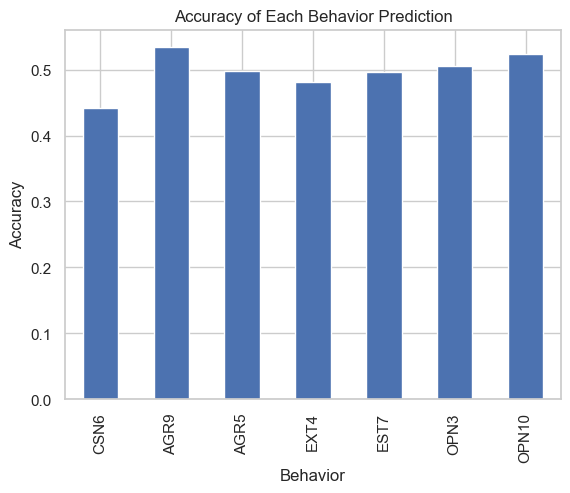

In [95]:
plt.figure()

results_df["Accuracy"].plot(
    kind="bar"
)

plt.title(
    "Accuracy of Each Behavior Prediction"
)

plt.ylabel(
    "Accuracy"
)

plt.xlabel(
    "Behavior"
)

plt.show()

5.6 Save Evaluation Results

In [96]:
results_df.to_csv(
    "model_evaluation_results.csv"
)

print("Results saved")

Results saved


# Step 6: Feature Importance Analysis

6.1 Calculate Feature Importance for All Targets

In [103]:
from sklearn.inspection import permutation_importance
feature_importance_results = {}

for target in target_columns:

    print("Calculating importance for:", target)

    model = models[target]

    X_test = datasets[target]["X_test"]
    y_test = datasets[target]["y_test"]

    X_test = X_test.fillna(X_test.mean())

    mask = y_test.notna()

    X_test = X_test[mask]

    y_test = y_test[mask]

    result = permutation_importance(
        model,
        X_test,
        y_test,
        n_repeats=5,
        random_state=42,
        n_jobs=-1
    )

    importance = pd.Series(
        result.importances_mean,
        index=feature_columns
    )

    importance = importance.sort_values(
        ascending=False
    )

    feature_importance_results[target] = importance

Calculating importance for: CSN6
Calculating importance for: AGR9
Calculating importance for: AGR5
Calculating importance for: EXT4
Calculating importance for: EST7
Calculating importance for: OPN3
Calculating importance for: OPN10


6.2 Plot Feature Importance (Top 15 per Target)


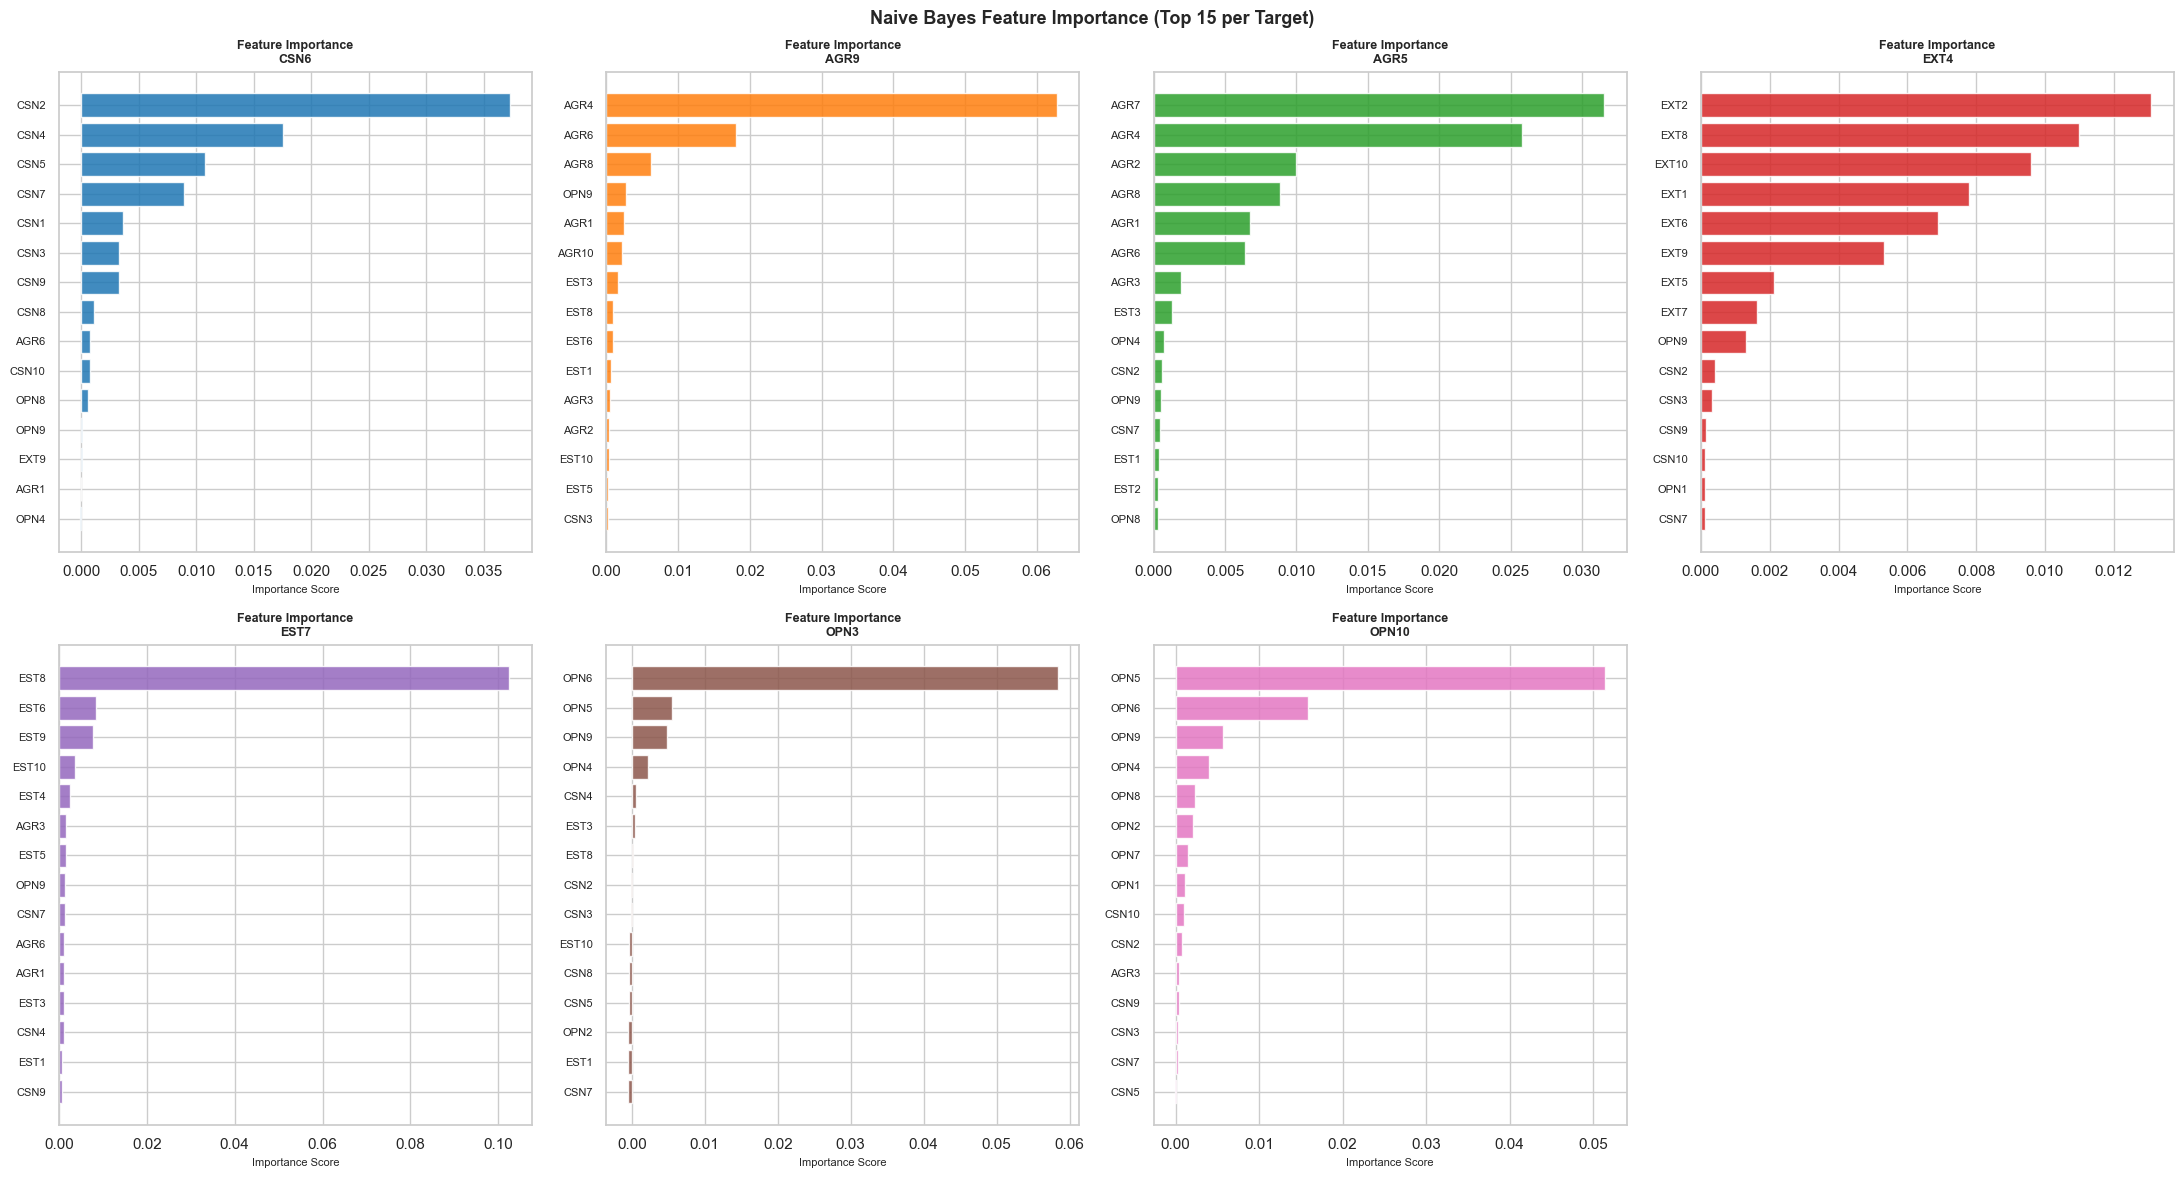

In [104]:
fig, axes = plt.subplots(
    2,
    4,
    figsize=(22, 12)
)

axes = axes.flatten()

colors = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b",
    "#e377c2"
]

for i, target in enumerate(target_columns):

    ax = axes[i]

    importance = feature_importance_results[target]

    top15 = importance.head(15)

    ax.barh(
        top15.index[::-1],
        top15.values[::-1],
        color=colors[i],
        alpha=0.85
    )

    ax.set_title(
        f"Feature Importance\n{target}",
        fontsize=9,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Importance Score",
        fontsize=8
    )

    ax.tick_params(
        axis="y",
        labelsize=8
    )

axes[-1].set_visible(False)

fig.suptitle(
    "Naive Bayes Feature Importance (Top 15 per Target)",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

6.3 Save Feature Importance Results

In [105]:
for target in target_columns:

    filename = f"feature_importance_{target}.csv"

    feature_importance_results[target].to_csv(
        filename
    )

print("Feature importance files saved")

Feature importance files saved


# Step 7: Final Model Summary — Naive Bayes

In [ ]:
from sklearn.metrics import mean_absolute_error

print('=' * 65)
print('           FINAL MODEL SUMMARY — NAIVE BAYES')
print('=' * 65)

print(f'  Total samples used     : {len(X):,}')
print(f'  Train / Test split     : 80% / 20%')
print(f'  Features               : {len(feature_columns)} columns')
print(f'  Targets (behaviors)    : {len(target_columns)} columns')

print('-' * 65)

print(f'  {"Target":<30} {"Train MAE":>12} {"Test MAE":>12}')

print('-' * 65)

summary_results = {}

for col in target_columns:
    X_train = datasets[col]["X_train"]
    X_test = datasets[col]["X_test"]
    y_train = datasets[col]["y_train"]
    y_test = datasets[col]["y_test"]

    mask_train = y_train.notna()
    mask_test = y_test.notna()

    X_train = X_train.loc[mask_train].fillna(X_train.mean())
    y_train = y_train.loc[mask_train]

    X_test = X_test.loc[mask_test].fillna(X_test.mean())
    y_test = y_test.loc[mask_test]

    y_train_pred = models[col].predict(X_train)
    y_test_pred = models[col].predict(X_test)

    mae_train = mean_absolute_error(y_train, y_train_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)

    summary_results[col] = {
        "MAE_train": mae_train,
        "MAE_test": mae_test
    }

    print(
        f'  {col:<30} '
        f'{mae_train:>12.4f} '
        f'{mae_test:>12.4f}'
    )

print('-' * 65)

avg_test = np.mean(
    [summary_results[c]['MAE_test'] for c in target_columns]
)

avg_train = np.mean(
    [summary_results[c]['MAE_train'] for c in target_columns]
)

print(
    f'  {"AVERAGE":<30} '
    f'{avg_train:>12.4f} '
    f'{avg_test:>12.4f}'
)

print('=' * 65)

print(
    f'\n  Scale: 1–5 → MAE < 0.5 ถือว่าอยู่ในเกณฑ์ดี'
)

print(
    f'         MAE ≈ {avg_test:.2f} '
    f'หมายความว่าโมเดลทำนายผิดพลาดเฉลี่ย '
    f'{avg_test:.2f} คะแนน'
)

           FINAL MODEL SUMMARY — NAIVE BAYES
  Total samples used     : 876,217
  Train / Test split     : 80% / 20%
  Features               : 43 columns
  Targets (behaviors)    : 43 columns
-----------------------------------------------------------------
  Target                            Train MAE     Test MAE
-----------------------------------------------------------------


KeyError: 'CSN6'